Handwritten Signature Verification (OCSVM: RAW vs HOG)


**Dataset:** CEDAR offline signature dataset (55 writers, 24 genuine + 24 forged signatures each)

This is a rebuilt version of the original pipeline. What changed and why:
pipeline_diagram
1. **Preprocessing now crops tightly to the ink before resizing.** The original pipeline resized the full scanned image (with all its blank margin) to 100x100. This version uses an Otsu threshold to find the ink pixels, crops to their bounding box first, *then* does the aspect-preserving resize and pad. This removes a source of noise that affected both RAW pixels and HOG equally.
2. **Hyperparameter tuning uses ONE data-driven grid, decided in advance.** The original pipeline tuned nu/gamma, saw the best gamma sitting at the edge of the tested range, widened the grid, saw it happen again, and repeated this four times eventually locking in gamma values so small (down to 1e-9) that the RBF kernel became nearly flat/degenerate by the pipeline's own diagnostic. This version instead computes a *reference* gamma for each feature representation from the data itself (matching sklearn's `gamma='scale'` heuristic: `1 / (n_features * variance)`), then sweeps a **fixed, bounded multiplier range** around that reference. The grid is defined once, before looking at any results, and is not touched afterward.
3. **No stale-variable bugs.** In the original notebook, some diagnostic tables (train/validation/test FRR progression) ended up referencing an old tuning run's results instead of the final locked hyperparameters, because of how the notebook was re-run out of order across many sessions. This version locks `RAW_NU`, `RAW_GAMMA`, `HOG_NU`, `HOG_GAMMA` in exactly one cell, and every downstream cell references those same variables nothing else defines or overwrites them.

Everything else (the writer-specific split, the OCSVM RBF-kernel design, the evaluation metrics) is unchanged from the original, since that part of the pipeline was already sound.

## Imports

In [1]:
import numpy as np
import pandas as pd

from PIL import Image, ImageOps
from math import floor, ceil
from skimage.feature import hog
from skimage.filters import threshold_otsu

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

import os
from pathlib import Path
from collections import Counter

import hashlib
import random

from scipy.spatial.distance import pdist

print("Imports loaded.")

Imports loaded.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Verification

Confirms the CEDAR dataset is mounted correctly and has the expected 1,320 genuine + 1,320 forged PNG files (55 writers x 24 each).

In [ ]:
DATASET_DIR = Path("")
GENUINE_DIR = DATASET_DIR / "full_org"
FORGED_DIR = DATASET_DIR / "full_forg"

print("Dataset directory:", DATASET_DIR)
print("Genuine directory:", GENUINE_DIR)
print("Forged directory:", FORGED_DIR)

genuine_files = sorted(GENUINE_DIR.glob("*.png"))
forged_files = sorted(FORGED_DIR.glob("*.png"))

print("Number of genuine PNG files:", len(genuine_files))
print("Number of forged PNG files:", len(forged_files))

assert len(genuine_files) == 1320, "Unexpected number of genuine PNG files!"
assert len(forged_files) == 1320, "Unexpected number of forged PNG files!"

print("\nDataset verification PASSED.")

## Extract Writer IDs

CEDAR filenames follow the pattern `original_<writer>_<index>.png` / `forgeries_<writer>_<index>.png`.

In [4]:
def get_writer_id(filepath):
    # Example filename: original_17_21.png -> writer 17
    return int(filepath.stem.split("_")[1])

genuine_writer_ids = [get_writer_id(f) for f in genuine_files]
forged_writer_ids = [get_writer_id(f) for f in forged_files]

genuine_writers = sorted(set(genuine_writer_ids))
forged_writers = sorted(set(forged_writer_ids))

print("Number of genuine writers:", len(genuine_writers))
print("Number of forged writers:", len(forged_writers))
assert len(genuine_writers) == 55 and len(forged_writers) == 55

Number of genuine writers: 55
Number of forged writers: 55


## Verify Signature Counts and Check for Duplicates

Every writer must have exactly 24 genuine and 24 forged signatures, and no image should be a byte-for-byte duplicate of another.

In [5]:
genuine_counts = Counter(genuine_writer_ids)
forged_counts = Counter(forged_writer_ids)

genuine_ok = all(count == 24 for count in genuine_counts.values())
forged_ok = all(count == 24 for count in forged_counts.values())

print("Every writer has 24 genuine signatures:", genuine_ok)
print("Every writer has 24 forged signatures:", forged_ok)

assert genuine_ok, "Some writers do not have exactly 24 genuine signatures."
assert forged_ok, "Some writers do not have exactly 24 forged signatures."

print("\nWriter signature-count verification PASSED.")

Every writer has 24 genuine signatures: True
Every writer has 24 forged signatures: True

Writer signature-count verification PASSED.


In [6]:
def image_hash(path):
    with Image.open(path) as img:
        img = img.convert("L")
        return hashlib.md5(img.tobytes()).hexdigest()

def find_duplicate_images(directory):
    hash_to_files = {}
    for path in sorted(directory.glob("*.png")):
        h = image_hash(path)
        hash_to_files.setdefault(h, []).append(path.name)
    return {h: files for h, files in hash_to_files.items() if len(files) > 1}

genuine_duplicates = find_duplicate_images(GENUINE_DIR)
forged_duplicates = find_duplicate_images(FORGED_DIR)

print("Genuine duplicate groups:", len(genuine_duplicates))
print("Forged duplicate groups:", len(forged_duplicates))
if not genuine_duplicates and not forged_duplicates:
    print("No duplicates found.")

Genuine duplicate groups: 0
Forged duplicate groups: 0
No duplicates found.


### Cross-class duplicate check (genuine ↔ forged)

The check above only compared genuine↔genuine and forged↔forged. It never checked whether any genuine image is pixel-identical to a forged image. A single such duplicate landing in different splits would silently corrupt the evaluation, so this closes that gap before anything else changes.

In [7]:
genuine_hash_map = {}
for p in sorted(GENUINE_DIR.glob("*.png")):
    genuine_hash_map.setdefault(image_hash(p), []).append(p.name)

forged_hash_map = {}
for p in sorted(FORGED_DIR.glob("*.png")):
    forged_hash_map.setdefault(image_hash(p), []).append(p.name)

cross_class_overlap = set(genuine_hash_map) & set(forged_hash_map)

print("Genuine<->Forged pixel-identical duplicate groups:", len(cross_class_overlap))
if cross_class_overlap:
    for h in cross_class_overlap:
        print("  GENUINE:", genuine_hash_map[h], " <-> FORGED:", forged_hash_map[h])
else:
    print("No genuine/forged cross-class duplicates found.")


Genuine<->Forged pixel-identical duplicate groups: 0
No genuine/forged cross-class duplicates found.


## Writer-Specific Train / Validation / Final-Test Split

Unchanged from the original design (this part was not broken). Per writer:

- 12 genuine -> OCSVM training
- 3 genuine + 12 forged -> validation (hyperparameter tuning)
- 3 genuine + 12 forged -> final test (touched exactly once, at the end)

Fixed random seed keeps the split reproducible across reruns.

In [8]:
RANDOM_SEED = 42
rng = random.Random(RANDOM_SEED)

writer_splits = {}

for writer_id in range(1, 56):

    w_genuine = sorted([p for p in GENUINE_DIR.glob("*.png") if get_writer_id(p) == writer_id])
    shuffled_genuine = w_genuine.copy()
    rng.shuffle(shuffled_genuine)

    train_genuine = shuffled_genuine[:12]
    validation_genuine = shuffled_genuine[12:15]
    final_test_genuine = shuffled_genuine[15:18]

    w_forged = sorted([p for p in FORGED_DIR.glob("*.png") if get_writer_id(p) == writer_id])
    shuffled_forged = w_forged.copy()
    rng.shuffle(shuffled_forged)

    validation_forged = shuffled_forged[:12]
    final_test_forged = shuffled_forged[12:24]

    writer_splits[writer_id] = {
        "train_genuine": train_genuine,
        "validation_genuine": validation_genuine,
        "validation_forged": validation_forged,
        "final_test_genuine": final_test_genuine,
        "final_test_forged": final_test_forged
    }

for writer_id, split in writer_splits.items():
    assert len(split["train_genuine"]) == 12
    assert len(split["validation_genuine"]) == 3
    assert len(split["validation_forged"]) == 12
    assert len(split["final_test_genuine"]) == 3
    assert len(split["final_test_forged"]) == 12

print("Writer-specific split verification PASSED.")
print("Training genuine:", sum(len(s["train_genuine"]) for s in writer_splits.values()))
print("Validation genuine:", sum(len(s["validation_genuine"]) for s in writer_splits.values()))
print("Validation forged:", sum(len(s["validation_forged"]) for s in writer_splits.values()))
print("Final-test genuine:", sum(len(s["final_test_genuine"]) for s in writer_splits.values()))
print("Final-test forged:", sum(len(s["final_test_forged"]) for s in writer_splits.values()))

Writer-specific split verification PASSED.
Training genuine: 660
Validation genuine: 165
Validation forged: 660
Final-test genuine: 165
Final-test forged: 660


## Preprocess Signature Images

**What changed from v1:** the original preprocessing (grayscale -> invert -> aspect-preserving resize -> pad) resized the *entire* scanned image, blank margin and all, to 100x100. Since each scan has a different amount of surrounding blank space, this meant the actual signature ended up at a different scale/position in the final 100x100 frame for almost every image adding noise to both the RAW pixel and HOG conditions equally.

**What changed from v2:** v2 added an Otsu-threshold crop to the ink bounding box, but cropping to the box of *any* ink pixel turned out to have a side effect on CEDAR: some signatures have a long, thin trailing flourish/squiggle stroke that extends far to one side. That single thin stroke stretched the crop's bounding box width dramatically without adding height, so the aspect-preserving resize crushed the actual signature body into a thin horizontal sliver with large black padding bars top and bottom (visible directly in the Step 5A visual check).

This version (v3) fixes that with two changes:

1. **Density-threshold cropping instead of any-ink cropping.** A row/column only counts as part of the signature's bounding box if its ink-pixel count is at least 5% of the busiest row/column's count. A thin flourish line (a handful of ink pixels per row) falls below this threshold and no longer drags the crop box out with it, while the actual signature body (many ink pixels per row) still defines the crop.
2. **A hard cap on the crop's aspect ratio** (`MAX_CROP_ASPECT = 2.5`). Even after density-thresholding, if a crop still comes out more elongated than this, the shorter dimension is padded before resizing so no signature can be squeezed to a sliver.

`BINARIZE_OUTPUT` is left as `False` by default (output stays grayscale, so HOG still sees soft gradient information at stroke edges). Set it to `True` later and re-run everything from Step 6 onward if you want to test a fully binarized variant as a supplementary comparison don't do both at once, since that would confound the RAW-vs-HOG comparison with a second preprocessing variable.

In [9]:
IMG_SIZE = (100, 100)
BINARIZE_OUTPUT = False  # set True only for a separate, supplementary experiment
MAX_CROP_ASPECT = 2.5    # cap on width:height (or height:width) after cropping
DENSITY_FRAC = 0.05      # a row/col counts as "signature" if ink >= 5% of the busiest row/col

def preprocess_signature(image_path, img_size=IMG_SIZE, binarize_output=BINARIZE_OUTPUT,
                          max_aspect=MAX_CROP_ASPECT, density_frac=DENSITY_FRAC):
    """
    Preprocess one signature image.

    Steps:
    1. Convert to grayscale
    2. Invert (ink becomes bright, background becomes dark)
    3. Otsu-threshold to find ink pixels
    4. Crop to rows/columns with a MEANINGFUL DENSITY of ink (not just any ink)
       -- this stops a thin trailing flourish stroke from stretching the crop
       and crushing the actual signature body
    5. Cap the crop's aspect ratio (pad the shorter side) so a genuinely
       elongated signature still can't get squeezed to a sliver
    6. Resize while preserving aspect ratio, center, and pad
    7. Optionally binarize the final output
    """
    target_width, target_height = img_size

    with Image.open(image_path) as im:
        im = im.convert("L")
        im = ImageOps.invert(im)
        img = np.asarray(im)

        # --- Otsu threshold -> ink mask ---
        if img.max() > img.min():
            thresh = threshold_otsu(img)
            ink_mask = img > thresh
        else:
            ink_mask = np.zeros_like(img, dtype=bool)

        # --- Density-threshold crop: ignore thin flourish strokes ---
        if ink_mask.any():
            row_counts = ink_mask.sum(axis=1)
            col_counts = ink_mask.sum(axis=0)
            row_thresh = max(2, row_counts.max() * density_frac)
            col_thresh = max(2, col_counts.max() * density_frac)

            sig_rows = row_counts >= row_thresh
            sig_cols = col_counts >= col_thresh

            if sig_rows.any() and sig_cols.any():
                top_b, bottom_b = np.where(sig_rows)[0][[0, -1]]
                left_b, right_b = np.where(sig_cols)[0][[0, -1]]
                img = img[top_b:bottom_b + 1, left_b:right_b + 1]
        # if no ink is detected (should not happen on CEDAR), skip cropping

        height, width = img.shape

        # --- Cap the crop's aspect ratio before resizing ---
        if width / height > max_aspect:
            target_h = ceil(width / max_aspect)  # FIXED: was int() (floor) -- could leave ratio slightly over max_aspect
            pad = max(0, target_h - height)
            img = np.pad(img, ((pad // 2, pad - pad // 2), (0, 0)), constant_values=0)
        elif height / width > max_aspect:
            target_w = ceil(height / max_aspect)  # FIXED: was int() (floor) -- could leave ratio slightly over max_aspect
            pad = max(0, target_w - width)
            img = np.pad(img, ((0, 0), (pad // 2, pad - pad // 2)), constant_values=0)

        height, width = img.shape

        new_width = min(target_width, max(1, width * target_height // height))
        new_height = max(1, height * new_width // width)

        im_cropped = Image.fromarray(img).resize((new_width, new_height))
        img = np.asarray(im_cropped)

        top = floor((target_height - new_height) / 2)
        bottom = ceil((target_height - new_height) / 2)
        left = floor((target_width - new_width) / 2)
        right = ceil((target_width - new_width) / 2)

        img = np.pad(img, ((top, bottom), (left, right)), mode="constant", constant_values=0)

        if binarize_output and img.max() > img.min():
            img = (img > threshold_otsu(img)).astype(np.uint8) * 255

    return img

print("Preprocessing function created (density-threshold crop + aspect cap + resize + pad).")
print("Target image size:", IMG_SIZE, " | MAX_CROP_ASPECT =", MAX_CROP_ASPECT, " | BINARIZE_OUTPUT =", BINARIZE_OUTPUT)

Preprocessing function created (density-threshold crop + aspect cap + resize + pad).
Target image size: (100, 100)  | MAX_CROP_ASPECT = 2.5  | BINARIZE_OUTPUT = False


### Visual check

Compare a few original images against the new preprocessing output. You should see the signature filling more of the 100x100 frame than in the original pipeline, since the blank margin is cropped away first.

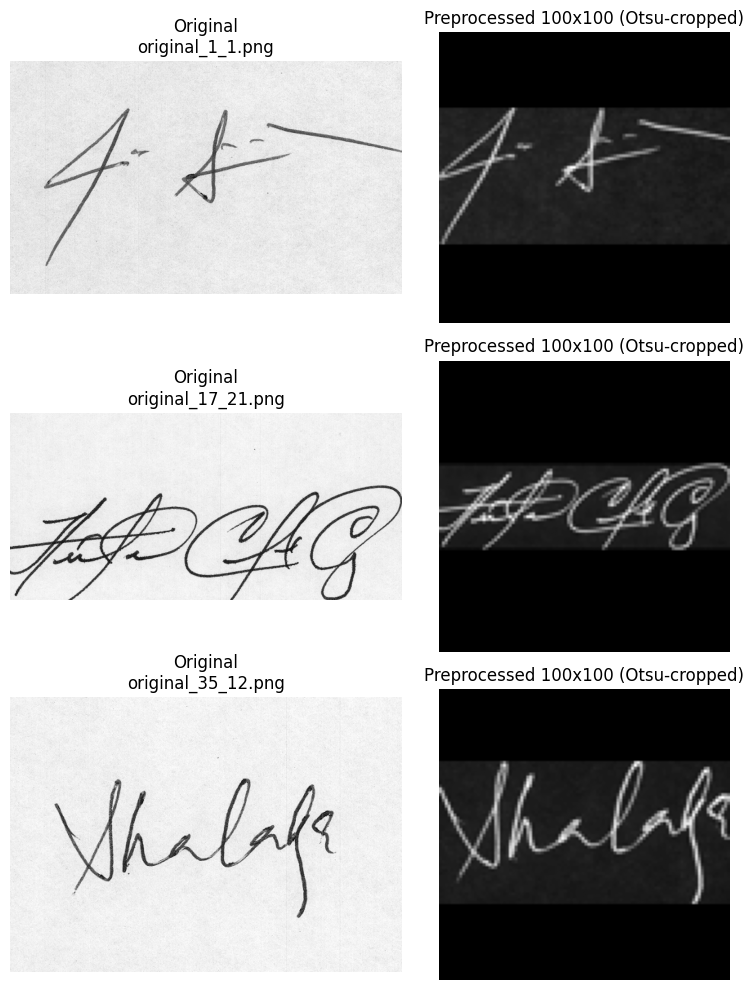

In [10]:
sample_files = [
    GENUINE_DIR / "original_1_1.png",
    GENUINE_DIR / "original_17_21.png",
    GENUINE_DIR / "original_35_12.png"
]

fig, axes = plt.subplots(len(sample_files), 2, figsize=(8, 10))

for row, image_path in enumerate(sample_files):
    original = Image.open(image_path).convert("L")
    processed = preprocess_signature(image_path)

    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].set_title(f"Original\n{image_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(processed, cmap="gray")
    axes[row, 1].set_title("Preprocessed 100x100 (Otsu-cropped)")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## RAW Pixel Features (Baseline)

Each preprocessed 100x100 image is flattened into a 10,000-value vector, normalized to [0, 1].

In [11]:
def create_raw_features(image_paths):
    features = []
    for path in image_paths:
        img = preprocess_signature(path)
        img = img.astype(np.float32) / 255.0
        features.append(img.flatten())
    return np.array(features)

print("RAW feature extraction function created.")

RAW feature extraction function created.


In [12]:
# Collect file lists from the writer-specific split
train_genuine_files = []
validation_genuine_files = []
validation_forged_files = []
final_test_genuine_files = []
final_test_forged_files = []

for writer_id, split in writer_splits.items():
    train_genuine_files.extend(split["train_genuine"])
    validation_genuine_files.extend(split["validation_genuine"])
    validation_forged_files.extend(split["validation_forged"])
    final_test_genuine_files.extend(split["final_test_genuine"])
    final_test_forged_files.extend(split["final_test_forged"])

print("Training genuine:", len(train_genuine_files))
print("Validation genuine:", len(validation_genuine_files))
print("Validation forged:", len(validation_forged_files))
print("Final-test genuine:", len(final_test_genuine_files))
print("Final-test forged:", len(final_test_forged_files))

Training genuine: 660
Validation genuine: 165
Validation forged: 660
Final-test genuine: 165
Final-test forged: 660


In [13]:
# NOTE: final-test files are NOT featurized here. They are deliberately left
# untouched until Step 10, after hyperparameters are locked in Step 9 -- see
# the note at the top of Step 10 for why.
X_train_raw = create_raw_features(train_genuine_files)
X_validation_genuine_raw = create_raw_features(validation_genuine_files)
X_validation_forged_raw = create_raw_features(validation_forged_files)

print("===== RAW FEATURE SHAPES (train + validation only) =====")
print("Training genuine:", X_train_raw.shape)
print("Validation genuine:", X_validation_genuine_raw.shape)
print("Validation forged:", X_validation_forged_raw.shape)

===== RAW FEATURE SHAPES (train + validation only) =====
Training genuine: (660, 10000)
Validation genuine: (165, 10000)
Validation forged: (660, 10000)


## HOG Features

Same preprocessing as the RAW branch, then a standard Dalal & Triggs HOG descriptor (9 orientations, 8x8 cells, 2x2 blocks, L2-Hys normalization).

In [14]:
def create_hog_features(image_paths):
    features = []
    for path in image_paths:
        img = preprocess_signature(path)
        img = img.astype(np.float32) / 255.0
        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True
        )
        features.append(hog_features)
    return np.array(features)

print("HOG feature extraction function created.")

HOG feature extraction function created.


In [15]:
# Same rule as the RAW branch: final-test files are not featurized here.
X_train_hog = create_hog_features(train_genuine_files)
X_validation_genuine_hog = create_hog_features(validation_genuine_files)
X_validation_forged_hog = create_hog_features(validation_forged_files)

print("===== HOG FEATURE SHAPES (train + validation only) =====")
print("Training genuine:", X_train_hog.shape)
print("Validation genuine:", X_validation_genuine_hog.shape)
print("Validation forged:", X_validation_forged_hog.shape)

===== HOG FEATURE SHAPES (train + validation only) =====
Training genuine: (660, 4356)
Validation genuine: (165, 4356)
Validation forged: (660, 4356)


## StandardScaler

Each scaler is fit ONLY on the 660 pooled training-genuine signatures, then applied to the validation data. Final-test data is intentionally NOT scaled here (see Step 10). RAW and HOG get separate scalers since they're different feature spaces.

**Design decision, stated explicitly: one GLOBAL scaler per feature representation, not one scaler per writer.**

Each writer's OCSVM is trained and evaluated independently, so it would be possible to fit a separate `StandardScaler` per writer using only that writer's 12 training-genuine signatures. This notebook deliberately does NOT do that, for a concrete statistical reason: estimating a mean and variance per feature from only 12 samples, in a 10,000-dimensional (RAW) or 4,356-dimensional (HOG) space, is far less stable than estimating it from all 660 pooled training-genuine signatures. A per-writer scaler would likely add noise rather than remove it, given how few samples each writer contributes.

Pooling across writers to fit the scaler does not leak writer identity into the OCSVM itself -- each writer's model still only ever trains on that writer's own (now-scaled) signatures. This is a preprocessing/normalization choice, not a change to the writer-independent modeling structure. This paragraph should be carried into Chapter 3 as the stated justification for using a global scaler, rather than leaving the choice implicit.

In [16]:
raw_scaler = StandardScaler()
hog_scaler = StandardScaler()

raw_scaler.fit(X_train_raw)
hog_scaler.fit(X_train_hog)

X_train_raw_scaled = raw_scaler.transform(X_train_raw)
X_validation_genuine_raw_scaled = raw_scaler.transform(X_validation_genuine_raw)
X_validation_forged_raw_scaled = raw_scaler.transform(X_validation_forged_raw)

X_train_hog_scaled = hog_scaler.transform(X_train_hog)
X_validation_genuine_hog_scaled = hog_scaler.transform(X_validation_genuine_hog)
X_validation_forged_hog_scaled = hog_scaler.transform(X_validation_forged_hog)

print("Scaling complete (train + validation only; final-test is scaled later, in Step 10).")
print("RAW train scaled shape:", X_train_raw_scaled.shape)
print("HOG train scaled shape:", X_train_hog_scaled.shape)

Scaling complete (train + validation only; final-test is scaled later, in Step 10).
RAW train scaled shape: (660, 10000)
HOG train scaled shape: (660, 4356)


## Tune OCSVM Hyperparameters (REWRITTEN)

**What changed from v1:** the original notebook picked an initial gamma grid, saw the best value land at the edge of the range, widened the grid, saw that happen again, and repeated this across four rounds ending with gamma values as small as 1e-9, which its own diagnostic flagged as making the RBF kernel "nearly flat/degenerate." Searching, watching the result, then re-searching in whichever direction improved the validation score is a good way to fit noise in a small validation set (55 writers x 15 samples each) rather than find a real optimum.

This version fixes that by anchoring the grid to the data itself instead of guessing exponents:

1. Compute a **reference gamma** for each feature representation using the same formula as sklearn's `gamma='scale'` default: `1 / (n_features * variance)`. Since RAW and HOG have very different dimensionality (10,000 vs 4,356 features), they naturally get different reference points.
2. Sweep a **fixed multiplier range** (0.01x to 100x) around each representation's own reference gamma. The multiplier range is the same for both RAW and HOG, which keeps the comparison fair, while the actual gamma values differ because they're anchored to each representation's own scale.
3. Run the tuning **exactly once** per representation and lock whatever comes out. No further widening after seeing the result.

A sanity check runs first, printing whether the smallest/largest gamma in each grid would produce a degenerate kernel, so you can see this *before* running the full search rather than discovering it after four rounds of retuning.

In [17]:
def gamma_scale_reference(X):
    """
    Data-driven reference gamma, matching sklearn's gamma='scale'
    heuristic: 1 / (n_features * X.var()). This is the CENTER of
    the hyperparameter grid below, rather than a value picked by
    eyeballing exponents.
    """
    return 1.0 / (X.shape[1] * X.var())

RAW_GAMMA_REF = gamma_scale_reference(X_train_raw_scaled)
HOG_GAMMA_REF = gamma_scale_reference(X_train_hog_scaled)

print("RAW reference gamma (sklearn 'scale' heuristic):", RAW_GAMMA_REF)
print("HOG reference gamma (sklearn 'scale' heuristic):", HOG_GAMMA_REF)

# Fixed multiplier grid, decided BEFORE looking at any validation
# results. Applied identically to both representations; the actual
# gamma values differ because each is anchored to its own reference.
GAMMA_MULTIPLIERS = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
NU_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]

RAW_GAMMA_VALUES = [m * RAW_GAMMA_REF for m in GAMMA_MULTIPLIERS]
HOG_GAMMA_VALUES = [m * HOG_GAMMA_REF for m in GAMMA_MULTIPLIERS]

print("\nRAW gamma grid:", [f"{g:.2e}" for g in RAW_GAMMA_VALUES])
print("HOG gamma grid:", [f"{g:.2e}" for g in HOG_GAMMA_VALUES])
print("\nNu grid (shared):", NU_VALUES)

RAW reference gamma (sklearn 'scale' heuristic): 0.00010023054
HOG reference gamma (sklearn 'scale' heuristic): 0.00022956831

RAW gamma grid: ['1.00e-06', '3.01e-06', '1.00e-05', '3.01e-05', '1.00e-04', '3.01e-04', '1.00e-03', '3.01e-03', '1.00e-02']
HOG gamma grid: ['2.30e-06', '6.89e-06', '2.30e-05', '6.89e-05', '2.30e-04', '6.89e-04', '2.30e-03', '6.89e-03', '2.30e-02']

Nu grid (shared): [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]


In [18]:
def kernel_scale_check(X_train, gamma, label):
    dists_sq = pdist(X_train, metric="sqeuclidean")
    mean_sq_dist = dists_sq.mean()
    product = gamma * mean_sq_dist
    flag = "  <-- WARNING: kernel nearly flat/degenerate" if product < 0.01 else ""
    print(f"{label}: gamma={gamma:.3e}  gamma*mean_sq_dist={product:.4f}{flag}")
    return product

print("=== Sanity check: smallest and largest gamma in each grid ===")
kernel_scale_check(X_train_raw_scaled, min(RAW_GAMMA_VALUES), "RAW (smallest gamma)")
kernel_scale_check(X_train_raw_scaled, max(RAW_GAMMA_VALUES), "RAW (largest gamma)")
kernel_scale_check(X_train_hog_scaled, min(HOG_GAMMA_VALUES), "HOG (smallest gamma)")
kernel_scale_check(X_train_hog_scaled, max(HOG_GAMMA_VALUES), "HOG (largest gamma)")
print("\nIf anything above is flagged, reconsider the multiplier range NOW,")
print("before running the full tuning grid below -- not after.")

=== Sanity check: smallest and largest gamma in each grid ===
RAW (smallest gamma): gamma=1.002e-06  gamma*mean_sq_dist=0.0200
RAW (largest gamma): gamma=1.002e-02  gamma*mean_sq_dist=200.3035
HOG (smallest gamma): gamma=2.296e-06  gamma*mean_sq_dist=0.0200
HOG (largest gamma): gamma=2.296e-02  gamma*mean_sq_dist=200.3034

If anything above is flagged, reconsider the multiplier range NOW,
before running the full tuning grid below -- not after.


In [19]:
def tune_ocsvm_validation(feature_type, X_train, X_val_genuine, X_val_forged,
                           train_files, val_genuine_files, val_forged_files,
                           nu_values, gamma_values):
    """
    Tune OCSVM hyperparameters using the validation set only.

    nu_values and gamma_values are passed in explicitly (not read from
    module-level globals), so a later cell can never silently reuse a
    stale or different grid than the one actually printed here.
    """
    results = []

    for nu in nu_values:
        for gamma in gamma_values:
            writer_f1, writer_far, writer_frr = [], [], []
            writer_accuracy, writer_precision, writer_recall = [], [], []

            for writer_id in range(1, 56):
                train_indices = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
                val_g_indices = [i for i, p in enumerate(val_genuine_files) if get_writer_id(p) == writer_id]
                val_f_indices = [i for i, p in enumerate(val_forged_files) if get_writer_id(p) == writer_id]

                assert len(train_indices) == 12
                assert len(val_g_indices) == 3
                assert len(val_f_indices) == 12

                X_writer_train = X_train[train_indices]
                X_writer_genuine = X_val_genuine[val_g_indices]
                X_writer_forged = X_val_forged[val_f_indices]

                X_writer_val = np.vstack([X_writer_genuine, X_writer_forged])
                y_writer_val = np.concatenate([np.ones(len(X_writer_genuine)), np.zeros(len(X_writer_forged))])

                model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
                model.fit(X_writer_train)

                y_pred = (model.predict(X_writer_val) == 1).astype(int)

                writer_accuracy.append(accuracy_score(y_writer_val, y_pred))
                writer_precision.append(precision_score(y_writer_val, y_pred, zero_division=0))
                writer_recall.append(recall_score(y_writer_val, y_pred, zero_division=0))
                writer_f1.append(f1_score(y_writer_val, y_pred, zero_division=0))

                genuine_preds = y_pred[:len(X_writer_genuine)]
                forged_preds = y_pred[len(X_writer_genuine):]
                writer_frr.append(np.mean(genuine_preds == 0))
                writer_far.append(np.mean(forged_preds == 1))

            results.append({
                "nu": nu, "gamma": gamma,
                "FAR": np.mean(writer_far), "FRR": np.mean(writer_frr),
                "Accuracy": np.mean(writer_accuracy), "Precision": np.mean(writer_precision),
                "Recall": np.mean(writer_recall), "F1": np.mean(writer_f1)
            })

    results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)

    print(f"\n===== {feature_type} VALIDATION TUNING (top 15 by F1) =====\n")
    display(results_df.head(15))

    best = results_df.iloc[0]
    print("\n===== SELECTED PARAMETERS =====")
    print("Feature type:", feature_type)
    print("nu =", best["nu"], " gamma =", best["gamma"])
    print("Mean F1 =", best["F1"], " Mean FRR =", best["FRR"], " Mean FAR =", best["FAR"])

    return results_df, best

print("Tuning function defined.")

Tuning function defined.


In [20]:
# Run tuning EXACTLY ONCE per representation, using the pre-specified
# grids from above. This replaces the old iterative widening entirely --
# whatever comes out below gets locked and used for everything downstream.

raw_tuning_results, best_raw = tune_ocsvm_validation(
    feature_type="RAW",
    X_train=X_train_raw_scaled,
    X_val_genuine=X_validation_genuine_raw_scaled,
    X_val_forged=X_validation_forged_raw_scaled,
    train_files=train_genuine_files,
    val_genuine_files=validation_genuine_files,
    val_forged_files=validation_forged_files,
    nu_values=NU_VALUES,
    gamma_values=RAW_GAMMA_VALUES
)

hog_tuning_results, best_hog = tune_ocsvm_validation(
    feature_type="HOG",
    X_train=X_train_hog_scaled,
    X_val_genuine=X_validation_genuine_hog_scaled,
    X_val_forged=X_validation_forged_hog_scaled,
    train_files=train_genuine_files,
    val_genuine_files=validation_genuine_files,
    val_forged_files=validation_forged_files,
    nu_values=NU_VALUES,
    gamma_values=HOG_GAMMA_VALUES
)

# Lock the final hyperparameters ONCE, here, and nowhere else in the notebook.
RAW_NU, RAW_GAMMA = float(best_raw["nu"]), float(best_raw["gamma"])
HOG_NU, HOG_GAMMA = float(best_hog["nu"]), float(best_hog["gamma"])

print("\n===== LOCKED FINAL HYPERPARAMETERS =====")
print("RAW: nu =", RAW_NU, " gamma =", RAW_GAMMA)
print("HOG: nu =", HOG_NU, " gamma =", HOG_GAMMA)
print("\nEvery cell below uses these exact variables. If you change the grid and")
print("re-run this cell, you MUST re-run every cell below it as well.")


===== RAW VALIDATION TUNING (top 15 by F1) =====



,nu,gamma,FAR,FRR,Accuracy,Precision,Recall,F1
0,0.15,0.000003,0.006061,0.775758,0.840000,0.530909,0.224242,0.306364
1,0.20,0.000003,0.006061,0.775758,0.840000,0.530909,0.224242,0.306364
2,0.10,0.000003,0.006061,0.781818,0.838788,0.512727,0.218182,0.297273
3,0.30,0.000003,0.006061,0.781818,0.838788,0.512727,0.218182,0.297273
4,0.25,0.000003,0.006061,0.781818,0.838788,0.512727,0.218182,0.297273
5,0.25,0.000001,0.006061,0.787879,0.837576,0.494545,0.212121,0.288182
6,0.15,0.000010,0.006061,0.793939,0.836364,0.512727,0.206061,0.286364
7,0.25,0.000010,0.006061,0.793939,0.836364,0.512727,0.206061,0.286364
8,0.20,0.000010,0.006061,0.793939,0.836364,0.512727,0.206061,0.286364
9,0.10,0.000010,0.006061,0.793939,0.836364,0.512727,0.206061,0.286364



===== SELECTED PARAMETERS =====
Feature type: RAW
nu = 0.15  gamma = 3.0069161311985226e-06
Mean F1 = 0.3063636363636364  Mean FRR = 0.7757575757575758  Mean FAR = 0.006060606060606061

===== HOG VALIDATION TUNING (top 15 by F1) =====



,nu,gamma,FAR,FRR,Accuracy,Precision,Recall,F1
0,0.20,0.000002,0.0,0.763636,0.847273,0.563636,0.236364,0.320000
1,0.15,0.000007,0.0,0.769697,0.846061,0.545455,0.230303,0.312727
2,0.20,0.000007,0.0,0.769697,0.846061,0.545455,0.230303,0.312727
3,0.30,0.000002,0.0,0.781818,0.843636,0.563636,0.218182,0.307273
4,0.10,0.000007,0.0,0.775758,0.844848,0.527273,0.224242,0.303636
5,0.25,0.000007,0.0,0.775758,0.844848,0.527273,0.224242,0.303636
6,0.30,0.000007,0.0,0.787879,0.842424,0.527273,0.212121,0.294545
7,0.25,0.000002,0.0,0.787879,0.842424,0.490909,0.212121,0.285455
8,0.05,0.000023,0.0,0.806061,0.838788,0.454545,0.193939,0.263636
9,0.15,0.000002,0.0,0.806061,0.838788,0.454545,0.193939,0.261818



===== SELECTED PARAMETERS =====
Feature type: HOG
nu = 0.2  gamma = 2.295683088959777e-06
Mean F1 = 0.32  Mean FRR = 0.7636363636363637  Mean FAR = 0.0

===== LOCKED FINAL HYPERPARAMETERS =====
RAW: nu = 0.15  gamma = 3.0069161311985226e-06
HOG: nu = 0.2  gamma = 2.295683088959777e-06

Every cell below uses these exact variables. If you change the grid and
re-run this cell, you MUST re-run every cell below it as well.


## Diagnostic: Per-Writer Kernel Scale Check (run BEFORE final test)

The Step 9 sanity check computed `gamma * mean_sq_dist` on the **pooled 660-signature** training set (all 55 writers together). But every OCSVM only ever trains on **one writer's 12 signatures**. Same-writer signatures are typically far more self-similar than signatures pooled across 55 different people, so the pooled check can look healthy (~0.02, just above the 0.01 warning line) while the kernel is actually near-degenerate at the scale each model really operates on.

This runs on training data only, so it is safe to check now, before final-test data is ever touched -- if it reveals a real problem, the fix belongs here, not after looking at test results.

In [21]:
def kernel_scale_check_per_writer(X_train, train_files, gamma, label):
    products = []
    for writer_id in range(1, 56):
        idx = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
        X_w = X_train[idx]
        dists_sq = pdist(X_w, metric="sqeuclidean")
        products.append(gamma * dists_sq.mean())
    products = np.array(products)
    n_degenerate = int((products < 0.01).sum())
    print(f"{label}: mean={products.mean():.4f}  min={products.min():.4f}  "
          f"max={products.max():.4f}  writers_below_0.01={n_degenerate}/55")
    return products

print("===== PER-WRITER KERNEL SCALE CHECK (locked gamma from Step 9) =====\n")
raw_perwriter_scale = kernel_scale_check_per_writer(X_train_raw_scaled, train_genuine_files, RAW_GAMMA, "RAW")
hog_perwriter_scale = kernel_scale_check_per_writer(X_train_hog_scaled, train_genuine_files, HOG_GAMMA, "HOG")

print("\nHow to read this: if MOST writers show a product well under 0.01, the kernel is")
print("near-flat at the scale each individual OCSVM actually trains on, even though the")
print("pooled check above passed. That points to re-deriving gamma from within-writer")
print("distances (optional cell below) BEFORE running the final-test cells further down.")
print("If most writers are close to or above the pooled value, the kernel scale is NOT")
print("the problem -- do not run the optional cell below, proceed to final evaluation as-is.")


===== PER-WRITER KERNEL SCALE CHECK (locked gamma from Step 9) =====

RAW: mean=0.0385  min=0.0020  max=0.2566  writers_below_0.01=11/55
HOG: mean=0.0116  min=0.0022  max=0.0398  writers_below_0.01=29/55

How to read this: if MOST writers show a product well under 0.01, the kernel is
near-flat at the scale each individual OCSVM actually trains on, even though the
pooled check above passed. That points to re-deriving gamma from within-writer
distances (optional cell below) BEFORE running the final-test cells further down.
If most writers are close to or above the pooled value, the kernel scale is NOT
the problem -- do not run the optional cell below, proceed to final evaluation as-is.


### Optional: re-anchor gamma to the within-writer distance scale

**Only run this if the diagnostic above showed most writers below the 0.01 threshold.** Do not run this alongside the original Step 9 result and then keep whichever looks better on validation -- that is exactly the kind of post-hoc, validation-chasing behavior this notebook's rewrite was meant to eliminate. Pick one gamma-reference approach based on the diagnostic evidence, decide before looking at final-test data, and lock it the same way Step 9 does.

In [22]:
# ONLY run this cell if the per-writer diagnostic indicated a degenerate kernel.
def within_writer_gamma_reference(X_train, train_files):
    per_writer_mean_sqdist = []
    for writer_id in range(1, 56):
        idx = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
        X_w = X_train[idx]
        per_writer_mean_sqdist.append(pdist(X_w, metric="sqeuclidean").mean())
    avg_within_writer_sqdist = np.mean(per_writer_mean_sqdist)
    # Anchors gamma so a "typical" within-writer pair gets kernel value e^-1,
    # same spirit as sklearn's 'scale' heuristic but calibrated to the
    # within-writer distance scale instead of the pooled cross-writer scale.
    return 1.0 / avg_within_writer_sqdist

RAW_GAMMA_REF_V2 = within_writer_gamma_reference(X_train_raw_scaled, train_genuine_files)
HOG_GAMMA_REF_V2 = within_writer_gamma_reference(X_train_hog_scaled, train_genuine_files)
print("RAW within-writer gamma reference:", RAW_GAMMA_REF_V2)
print("HOG within-writer gamma reference:", HOG_GAMMA_REF_V2)

RAW_GAMMA_VALUES_V2 = [m * RAW_GAMMA_REF_V2 for m in GAMMA_MULTIPLIERS]
HOG_GAMMA_VALUES_V2 = [m * HOG_GAMMA_REF_V2 for m in GAMMA_MULTIPLIERS]

raw_tuning_results_v2, best_raw_v2 = tune_ocsvm_validation(
    feature_type="RAW (within-writer gamma ref)", X_train=X_train_raw_scaled,
    X_val_genuine=X_validation_genuine_raw_scaled, X_val_forged=X_validation_forged_raw_scaled,
    train_files=train_genuine_files, val_genuine_files=validation_genuine_files,
    val_forged_files=validation_forged_files, nu_values=NU_VALUES, gamma_values=RAW_GAMMA_VALUES_V2)

hog_tuning_results_v2, best_hog_v2 = tune_ocsvm_validation(
    feature_type="HOG (within-writer gamma ref)", X_train=X_train_hog_scaled,
    X_val_genuine=X_validation_genuine_hog_scaled, X_val_forged=X_validation_forged_hog_scaled,
    train_files=train_genuine_files, val_genuine_files=validation_genuine_files,
    val_forged_files=validation_forged_files, nu_values=NU_VALUES, gamma_values=HOG_GAMMA_VALUES_V2)

print("\nIf you adopt this, overwrite RAW_NU/RAW_GAMMA and HOG_NU/HOG_GAMMA with")
print("best_raw_v2 / best_hog_v2 BEFORE running the final-test cells below --")
print("do not evaluate under both gammas and choose the better-looking final result.")
# RAW_NU, RAW_GAMMA = float(best_raw_v2["nu"]), float(best_raw_v2["gamma"])
# HOG_NU, HOG_GAMMA = float(best_hog_v2["nu"]), float(best_hog_v2["gamma"])


RAW within-writer gamma reference: 7.81008363814618e-05
HOG within-writer gamma reference: 0.00019867318935206694

===== RAW (within-writer gamma ref) VALIDATION TUNING (top 15 by F1) =====



,nu,gamma,FAR,FRR,Accuracy,Precision,Recall,F1
0,0.20,2.343025e-06,0.006061,0.775758,0.840000,0.530909,0.224242,0.306364
1,0.15,2.343025e-06,0.006061,0.781818,0.838788,0.512727,0.218182,0.297273
2,0.25,2.343025e-06,0.006061,0.781818,0.838788,0.512727,0.218182,0.297273
3,0.30,2.343025e-06,0.006061,0.781818,0.838788,0.512727,0.218182,0.297273
4,0.20,7.810084e-06,0.006061,0.787879,0.837576,0.512727,0.212121,0.291818
5,0.15,7.810084e-06,0.006061,0.787879,0.837576,0.512727,0.212121,0.291818
6,0.10,7.810084e-06,0.006061,0.787879,0.837576,0.512727,0.212121,0.291818
7,0.30,7.810084e-06,0.006061,0.787879,0.837576,0.512727,0.212121,0.291818
8,0.25,7.810084e-06,0.006061,0.787879,0.837576,0.512727,0.212121,0.291818
9,0.30,7.810084e-07,0.006061,0.787879,0.837576,0.494545,0.212121,0.288182



===== SELECTED PARAMETERS =====
Feature type: RAW (within-writer gamma ref)
nu = 0.2  gamma = 2.3430250914438536e-06
Mean F1 = 0.3063636363636364  Mean FRR = 0.7757575757575758  Mean FAR = 0.006060606060606061

===== HOG (within-writer gamma ref) VALIDATION TUNING (top 15 by F1) =====



,nu,gamma,FAR,FRR,Accuracy,Precision,Recall,F1
0,0.15,0.000006,0.0,0.769697,0.846061,0.545455,0.230303,0.312727
1,0.20,0.000006,0.0,0.769697,0.846061,0.545455,0.230303,0.312727
2,0.30,0.000002,0.0,0.781818,0.843636,0.563636,0.218182,0.307273
3,0.25,0.000006,0.0,0.775758,0.844848,0.527273,0.224242,0.303636
4,0.20,0.000002,0.0,0.781818,0.843636,0.545455,0.218182,0.301818
5,0.10,0.000006,0.0,0.781818,0.843636,0.527273,0.218182,0.298182
6,0.30,0.000006,0.0,0.787879,0.842424,0.527273,0.212121,0.294545
7,0.25,0.000002,0.0,0.793939,0.841212,0.472727,0.206061,0.276364
8,0.15,0.000020,0.0,0.800000,0.840000,0.490909,0.200000,0.276364
9,0.25,0.000020,0.0,0.800000,0.840000,0.490909,0.200000,0.276364



===== SELECTED PARAMETERS =====
Feature type: HOG (within-writer gamma ref)
nu = 0.15  gamma = 5.960195680562008e-06
Mean F1 = 0.3127272727272727  Mean FRR = 0.7696969696969694  Mean FAR = 0.0

If you adopt this, overwrite RAW_NU/RAW_GAMMA and HOG_NU/HOG_GAMMA with
best_raw_v2 / best_hog_v2 BEFORE running the final-test cells below --
do not evaluate under both gammas and choose the better-looking final result.


## Final Training and Final Testing

The locked `RAW_NU`/`RAW_GAMMA`/`HOG_NU`/`HOG_GAMMA` from Step 9 are used here and are not changed again. Each writer's OCSVM is trained on that writer's 12 genuine training signatures and evaluated on their 3 genuine + 12 forged final-test signatures.

**This is the only cell in the entire notebook that reads `final_test_genuine_files` / `final_test_forged_files` to build features.** In earlier versions of this notebook, final-test RAW/HOG features were computed and scaled back in Steps 6-8, alongside train/validation features, well before hyperparameter tuning ran. That never leaked final-test labels or metrics into tuning (Step 9 only ever looked at validation-set results), but it was a real procedural inconsistency with the "final-test touched exactly once" claim -- the features existed and were sitting in memory before nu/gamma were locked. This version removes that: final-test images are not read, featurized, or scaled anywhere until this cell, which runs strictly after Step 9 has locked the hyperparameters.

In [23]:
def final_evaluation(feature_type, X_train, X_test_genuine, X_test_forged,
                      train_files, test_genuine_files, test_forged_files,
                      nu, gamma):
    """
    Final writer-specific OCSVM evaluation.
    Training: 12 genuine signatures per writer.
    Testing: 3 genuine + 12 forged signatures per writer.
    """
    writer_results = []

    for writer_id in range(1, 56):
        train_indices = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
        test_g_indices = [i for i, p in enumerate(test_genuine_files) if get_writer_id(p) == writer_id]
        test_f_indices = [i for i, p in enumerate(test_forged_files) if get_writer_id(p) == writer_id]

        assert len(train_indices) == 12
        assert len(test_g_indices) == 3
        assert len(test_f_indices) == 12

        X_writer_train = X_train[train_indices]
        X_writer_genuine = X_test_genuine[test_g_indices]
        X_writer_forged = X_test_forged[test_f_indices]
        X_writer_test = np.vstack([X_writer_genuine, X_writer_forged])
        y_writer_test = np.concatenate([np.ones(len(X_writer_genuine)), np.zeros(len(X_writer_forged))])

        model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
        model.fit(X_writer_train)

        y_pred = (model.predict(X_writer_test) == 1).astype(int)

        accuracy = accuracy_score(y_writer_test, y_pred)
        precision = precision_score(y_writer_test, y_pred, zero_division=0)
        recall = recall_score(y_writer_test, y_pred, zero_division=0)
        f1 = f1_score(y_writer_test, y_pred, zero_division=0)

        genuine_predictions = y_pred[:len(X_writer_genuine)]
        forged_predictions = y_pred[len(X_writer_genuine):]
        frr = np.mean(genuine_predictions == 0)
        far = np.mean(forged_predictions == 1)

        writer_results.append({
            "Writer": writer_id, "FAR": far, "FRR": frr,
            "Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1": f1
        })

    writer_results_df = pd.DataFrame(writer_results)

    overall_results = {
        "Feature": feature_type, "nu": nu, "gamma": gamma,
        "FAR": writer_results_df["FAR"].mean(),
        "FRR": writer_results_df["FRR"].mean(),
        "Accuracy": writer_results_df["Accuracy"].mean(),
        "Precision": writer_results_df["Precision"].mean(),
        "Recall": writer_results_df["Recall"].mean(),
        "F1": writer_results_df["F1"].mean()
    }

    return writer_results_df, overall_results

print("Final evaluation function defined.")

Final evaluation function defined.


In [24]:
# Final-test features + scaling (uses the scalers fit in Step 8 on
# training-genuine data only -- final-test data is only ever transformed).

X_final_test_genuine_raw = create_raw_features(final_test_genuine_files)
X_final_test_forged_raw = create_raw_features(final_test_forged_files)
X_final_test_genuine_hog = create_hog_features(final_test_genuine_files)
X_final_test_forged_hog = create_hog_features(final_test_forged_files)

X_final_test_genuine_raw_scaled = raw_scaler.transform(X_final_test_genuine_raw)
X_final_test_forged_raw_scaled = raw_scaler.transform(X_final_test_forged_raw)
X_final_test_genuine_hog_scaled = hog_scaler.transform(X_final_test_genuine_hog)
X_final_test_forged_hog_scaled = hog_scaler.transform(X_final_test_forged_hog)

print("Final-test features created and scaled.")
print("RAW genuine/forged:", X_final_test_genuine_raw_scaled.shape, X_final_test_forged_raw_scaled.shape)
print("HOG genuine/forged:", X_final_test_genuine_hog_scaled.shape, X_final_test_forged_hog_scaled.shape)

Final-test features created and scaled.
RAW genuine/forged: (165, 10000) (660, 10000)
HOG genuine/forged: (165, 4356) (660, 4356)


In [25]:
# Run final evaluation exactly once per representation, using the LOCKED
# hyperparameters from Step 9. This is the only place final evaluation runs.

raw_writer_results, raw_final_results = final_evaluation(
    feature_type="RAW",
    X_train=X_train_raw_scaled,
    X_test_genuine=X_final_test_genuine_raw_scaled,
    X_test_forged=X_final_test_forged_raw_scaled,
    train_files=train_genuine_files,
    test_genuine_files=final_test_genuine_files,
    test_forged_files=final_test_forged_files,
    nu=RAW_NU, gamma=RAW_GAMMA
)
raw_writer_df = pd.DataFrame(raw_writer_results)

hog_writer_results, hog_final_results = final_evaluation(
    feature_type="HOG",
    X_train=X_train_hog_scaled,
    X_test_genuine=X_final_test_genuine_hog_scaled,
    X_test_forged=X_final_test_forged_hog_scaled,
    train_files=train_genuine_files,
    test_genuine_files=final_test_genuine_files,
    test_forged_files=final_test_forged_files,
    nu=HOG_NU, gamma=HOG_GAMMA
)
hog_writer_df = pd.DataFrame(hog_writer_results)

print("RAW final evaluation completed.")
print("HOG final evaluation completed.")

RAW final evaluation completed.
HOG final evaluation completed.


### Overfitting diagnostic: Train -> Validation -> Final-Test FRR

This reuses `best_raw`/`best_hog` from the single Step 9 tuning run above (not a separately-run or older grid), so the progression below is guaranteed to describe the same locked model used in the final comparison.

In [26]:
def training_self_prediction(feature_type, X_train, train_files, nu, gamma):
    """
    For each writer, train OCSVM on their 12 genuine training signatures,
    then predict on those SAME 12 signatures.
    """
    writer_results = []
    for writer_id in range(1, 56):
        train_indices = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
        assert len(train_indices) == 12
        X_writer_train = X_train[train_indices]

        model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
        model.fit(X_writer_train)

        y_pred = (model.predict(X_writer_train) == 1).astype(int)
        writer_results.append({
            "Writer": writer_id,
            "Train_FRR": np.mean(y_pred == 0),
            "Train_Acceptance_Rate": np.mean(y_pred == 1)
        })

    writer_results_df = pd.DataFrame(writer_results)
    overall = {
        "Feature": feature_type, "nu": nu, "gamma": gamma,
        "Mean_Train_FRR": writer_results_df["Train_FRR"].mean(),
        "Mean_Train_Acceptance_Rate": writer_results_df["Train_Acceptance_Rate"].mean()
    }
    return writer_results_df, overall

raw_train_diag_df, raw_train_diag_summary = training_self_prediction(
    "RAW", X_train_raw_scaled, train_genuine_files, RAW_NU, RAW_GAMMA
)
hog_train_diag_df, hog_train_diag_summary = training_self_prediction(
    "HOG", X_train_hog_scaled, train_genuine_files, HOG_NU, HOG_GAMMA
)

print("===== TRAINING-SET SELF-PREDICTION SUMMARY =====\n")
display(pd.DataFrame([raw_train_diag_summary, hog_train_diag_summary]))

frr_progression = pd.DataFrame([
    {
        "Feature": "RAW",
        "Train_FRR": raw_train_diag_summary["Mean_Train_FRR"],
        "Validation_FRR": best_raw["FRR"],   # same tuning run as locked above
        "Final_Test_FRR": raw_final_results["FRR"]
    },
    {
        "Feature": "HOG",
        "Train_FRR": hog_train_diag_summary["Mean_Train_FRR"],
        "Validation_FRR": best_hog["FRR"],   # same tuning run as locked above
        "Final_Test_FRR": hog_final_results["FRR"]
    }
])

print("\n===== TRAIN -> VALIDATION -> FINAL-TEST FRR PROGRESSION =====\n")
display(frr_progression)
print("\nInterpretation: Training FRR ~0%% with high Validation/Test FRR would")
print("indicate classic overfitting. Training FRR ALSO being high instead points")
print("to a hyperparameter or feature-representation issue rather than overfitting.")

===== TRAINING-SET SELF-PREDICTION SUMMARY =====



,Feature,nu,gamma,Mean_Train_FRR,Mean_Train_Acceptance_Rate
0,RAW,0.15,0.000003,0.425758,0.574242
1,HOG,0.20,0.000002,0.466667,0.533333



===== TRAIN -> VALIDATION -> FINAL-TEST FRR PROGRESSION =====



,Feature,Train_FRR,Validation_FRR,Final_Test_FRR
0,RAW,0.425758,0.775758,0.848485
1,HOG,0.466667,0.763636,0.836364



Interpretation: Training FRR ~0%% with high Validation/Test FRR would
indicate classic overfitting. Training FRR ALSO being high instead points
to a hyperparameter or feature-representation issue rather than overfitting.


## RAW vs HOG Final-Test Comparison

In [27]:
final_comparison = pd.DataFrame([raw_final_results, hog_final_results])
print("\n===== FINAL RAW vs HOG RESULTS =====\n")
display(final_comparison)


===== FINAL RAW vs HOG RESULTS =====



,Feature,nu,gamma,FAR,FRR,Accuracy,Precision,Recall,F1
0,RAW,0.15,0.000003,0.009091,0.848485,0.823030,0.329870,0.151515,0.198182
1,HOG,0.20,0.000002,0.000000,0.836364,0.832727,0.436364,0.163636,0.234545


In [28]:
comparison_metrics = ["FAR", "FRR", "Accuracy", "Precision", "Recall", "F1"]
winner_rows = []

for metric in comparison_metrics:
    raw_value = raw_final_results[metric]
    hog_value = hog_final_results[metric]

    if metric in ["FAR", "FRR"]:
        winner = "RAW" if raw_value < hog_value else ("HOG" if hog_value < raw_value else "Tie")
    else:
        winner = "RAW" if raw_value > hog_value else ("HOG" if hog_value > raw_value else "Tie")

    winner_rows.append({"Metric": metric, "RAW": raw_value, "HOG": hog_value, "Better Model": winner})

metric_winner_df = pd.DataFrame(winner_rows)
display(metric_winner_df)

,Metric,RAW,HOG,Better Model
0,FAR,0.009091,0.000000,HOG
1,FRR,0.848485,0.836364,HOG
2,Accuracy,0.823030,0.832727,HOG
3,Precision,0.329870,0.436364,HOG
4,Recall,0.151515,0.163636,HOG
5,F1,0.198182,0.234545,HOG


## Trivial Baselines and Balanced Accuracy

Ordinary accuracy is misleading here because the final test set is 165 genuine vs 660 forged (20/80). These baselines and balanced accuracy give an honest reference point for the discussion section.

In [29]:
n_test_genuine = len(final_test_genuine_files)
n_test_forged = len(final_test_forged_files)
n_test_total = n_test_genuine + n_test_forged

def balanced_accuracy(far, frr):
    return ((1 - frr) + (1 - far)) / 2

reject_all = {"Feature": "Reject-All Baseline", "FAR": 0.0, "FRR": 1.0,
              "Accuracy": n_test_forged / n_test_total,
              "Precision": float("nan"), "Recall": 0.0, "F1": 0.0}
p_accept = n_test_genuine / n_test_total
accept_all = {"Feature": "Accept-All Baseline", "FAR": 1.0, "FRR": 0.0,
              "Accuracy": p_accept, "Precision": p_accept, "Recall": 1.0,
              "F1": 2 * p_accept / (1 + p_accept)}

baseline_comparison = pd.DataFrame([
    {**raw_final_results, "Balanced_Accuracy": balanced_accuracy(raw_final_results["FAR"], raw_final_results["FRR"])},
    {**hog_final_results, "Balanced_Accuracy": balanced_accuracy(hog_final_results["FAR"], hog_final_results["FRR"])},
    {**reject_all, "Balanced_Accuracy": balanced_accuracy(reject_all["FAR"], reject_all["FRR"])},
    {**accept_all, "Balanced_Accuracy": balanced_accuracy(accept_all["FAR"], accept_all["FRR"])},
])

print("===== FINAL RESULTS vs TRIVIAL BASELINES =====\n")
display(baseline_comparison[["Feature", "FAR", "FRR", "Accuracy", "Balanced_Accuracy", "Precision", "Recall", "F1"]])


===== FINAL RESULTS vs TRIVIAL BASELINES =====



,Feature,FAR,FRR,Accuracy,Balanced_Accuracy,Precision,Recall,F1
0,RAW,0.009091,0.848485,0.823030,0.571212,0.329870,0.151515,0.198182
1,HOG,0.000000,0.836364,0.832727,0.581818,0.436364,0.163636,0.234545
2,Reject-All Baseline,0.000000,1.000000,0.800000,0.500000,NaN,0.000000,0.000000
3,Accept-All Baseline,1.000000,0.000000,0.200000,0.500000,0.200000,1.000000,0.333333


## Writer-Level Analysis

Since every writer has the same final-test composition (3 genuine + 12 forged), writer-level results are directly comparable.

In [30]:
writer_comparison = pd.DataFrame({
    "Writer": raw_writer_df["Writer"],
    "RAW_FRR": raw_writer_df["FRR"],
    "HOG_FRR": hog_writer_df["FRR"],
    "RAW_F1": raw_writer_df["F1"],
    "HOG_F1": hog_writer_df["F1"]
})

writer_comparison["FRR Difference (HOG - RAW)"] = writer_comparison["HOG_FRR"] - writer_comparison["RAW_FRR"]
writer_comparison["F1 Difference (HOG - RAW)"] = writer_comparison["HOG_F1"] - writer_comparison["RAW_F1"]

display(writer_comparison)

,Writer,RAW_FRR,HOG_FRR,RAW_F1,HOG_F1,FRR Difference (HOG - RAW),F1 Difference (HOG - RAW)
0,1,1.000000,1.000000,0.0,0.0,0.000000,0.0
1,2,1.000000,1.000000,0.0,0.0,0.000000,0.0
2,3,0.666667,0.666667,0.5,0.5,0.000000,0.0
3,4,0.666667,1.000000,0.5,0.0,0.333333,-0.5
4,5,0.666667,1.000000,0.5,0.0,0.333333,-0.5
5,6,0.666667,0.666667,0.5,0.5,0.000000,0.0
6,7,1.000000,0.666667,0.0,0.5,-0.333333,0.5
7,8,1.000000,0.666667,0.0,0.5,-0.333333,0.5
8,9,1.000000,0.666667,0.0,0.5,-0.333333,0.5
9,10,1.000000,0.666667,0.0,0.5,-0.333333,0.5


In [31]:
writer_comparison["F1 Winner"] = "Tie"
writer_comparison.loc[writer_comparison["RAW_F1"] > writer_comparison["HOG_F1"], "F1 Winner"] = "RAW"
writer_comparison.loc[writer_comparison["HOG_F1"] > writer_comparison["RAW_F1"], "F1 Winner"] = "HOG"

f1_winner_counts = (
    writer_comparison["F1 Winner"]
    .value_counts()
    .reindex(["RAW", "HOG", "Tie"], fill_value=0)
    .reset_index()
)
f1_winner_counts.columns = ["Model", "Number of Writers"]
display(f1_winner_counts)

,Model,Number of Writers
0,RAW,12
1,HOG,16
2,Tie,27


## Notes for the write-up

- If the final RAW vs HOG numbers still look off after this rebuild (e.g. FRR still high for both), that's useful information, not a sign something is broken it may mean 12 genuine training signatures per writer is simply a hard regime for both representations, which is itself worth discussing in Chapter 4/5 as a limitation rather than something to keep re-tuning away.
- Do not re-introduce the old pattern of "run tuning, see the result, widen the grid, re-run." If you genuinely believe the multiplier range in Step 9 is wrong, change it once, document why, and re-run the whole notebook from Step 9 down don't chase the validation score interactively.
- To test the `BINARIZE_OUTPUT=True` variant as a supplementary check, change that flag in Step 5 and re-run every cell from Step 6 onward. Treat it as a separate reported result, not a replacement for the grayscale version, unless you decide deliberately to switch the whole study to it.